# 09_delta_analysis.ipynb

> Main analysis: additional instability relative to the repeat baseline
> Computes case-level deltas for each pipeline factor, estimates confidence
> intervals by case-level cluster bootstrap, and compares the domains. This
> notebook produces the headline results of the study.

C:\Users\User\anaconda3\envs\xai-stability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pairs: 472,500   case-level rows: 4,340
Primary metrics: ['feature_distance', 'direction_distance', 'rank_distance']
Contrast counts:
contrast
llm_change       175500
multi_change     124200
repeat            89100
model_change      39600
prompt_change     24300
xai_change        19800
Case-level deltas: 2,220 rows
block    contrast     
A        model_change     300
         xai_change       300
A_prime  model_change     300
         xai_change       300
B        llm_change       300
         prompt_change    300
C        llm_change       100
         model_change     100
         xai_change       100
D        llm_change        60
D0       llm_change        60
Saved: tab39_delta_main_results.csv

Primary metrics, primary domain:
Block Domain     Factor             Metric  Baseline  Changed  Delta  CI low  CI high  N cases Excludes zero  Primary
    A credit      Model   Feature distance    0.1234   0.4485 0.3250  0.3128   0.3367      300          True     True
    A credit      Model 

,Metric,Rank,Factor,Block,Delta,CI,Excludes zero
0,Feature distance,1,XAI method,A,0.7048,"[0.6917, 0.7182]",True
1,Feature distance,2,Model,A,0.3250,"[0.3128, 0.3367]",True
2,Feature distance,3,Prompt,B,0.0157,"[0.0128, 0.0186]",True
3,Feature distance,4,LLM,B,0.0086,"[0.0066, 0.0107]",True
4,Direction distance,1,XAI method,A,0.0594,"[0.0387, 0.0801]",True
5,Direction distance,2,LLM,B,0.0066,"[0.0035, 0.0105]",True
6,Direction distance,3,Prompt,B,0.0062,"[0.0032, 0.0096]",True
7,Direction distance,4,Model,A,0.0039,"[0.0005, 0.0079]",True
8,Rank distance,1,XAI method,A,0.4957,"[0.3427, 0.6553]",True
9,Rank distance,2,Model,A,0.3094,"[0.2848, 0.3359]",True


Saved: tab41_factor_comparisons.csv


,Metric,Comparison,Difference,CI low,CI high,N cases,Excludes zero,Block
0,Feature distance,Model - XAI method,-0.3798,-0.3939,-0.3654,300,True,A
1,Feature distance,LLM - Prompt,-0.0071,-0.0094,-0.0048,300,True,B
2,Direction distance,Model - XAI method,-0.0555,-0.0767,-0.0356,299,True,A
3,Direction distance,LLM - Prompt,0.0004,-0.0001,0.0011,300,False,B
4,Rank distance,Model - XAI method,-0.2043,-0.3643,-0.0409,58,True,A
5,Rank distance,LLM - Prompt,-0.0213,-0.0286,-0.0148,300,True,B


...

Saved: tab44_delta_distributions.csv


,Block,Factor,Metric,Mean,Median,Q1,Q3,P90,Share above 0.10,Share above 0.20,Share negative
0,A,Model,Feature distance,0.3250,0.3291,0.2610,0.3980,0.4606,0.9767,0.8700,0.0000
1,A,Model,Direction distance,0.0039,0.0000,0.0000,0.0000,0.0140,0.0200,0.0067,0.1467
2,A,Model,Rank distance,0.3094,0.2727,0.1465,0.4368,0.6058,0.8467,0.6133,0.0733
3,A,XAI method,Feature distance,0.7048,0.7056,0.6295,0.7886,0.8489,1.0000,1.0000,0.0000
4,A,XAI method,Direction distance,0.0594,0.0000,0.0000,0.0000,0.2897,0.1438,0.1137,0.1906
5,A,XAI method,Rank distance,0.4957,0.5529,-0.0518,0.6667,1.3333,0.6207,0.6207,0.3793
6,B,LLM,Feature distance,0.0086,0.0000,0.0000,0.0148,0.0301,0.0000,0.0000,0.1300
7,B,LLM,Direction distance,0.0066,0.0000,0.0000,0.0000,0.0000,0.0200,0.0100,0.0300
8,B,LLM,Rank distance,0.0321,0.0000,-0.0000,0.0403,0.1185,0.1267,0.0333,0.2967
9,B,Prompt,Feature distance,0.0157,0.0000,0.0000,0.0255,0.0570,0.0100,0.0000,0.0367


Share of cases with a negative delta:
count    12.0000
mean      0.1314
std       0.1287
min       0.0000
25%       0.0275
50%       0.1016
75%       0.2113
max       0.3793

NOTE: in some cells more than 30 per cent of cases show a negative delta. Report the full distribution rather than the mean alone.
Saved: tab45_delta_coverage.csv
Maximum undefined share across cells: 0.8067
NOTE: substantial undefined coverage. Cases where explanations share no features are excluded by construction and represent the most extreme divergence; report this alongside the estimates.


,Block,Factor,Metric,N cases total,N cases with value,Undefined share
0,A,Model,Feature distance,300,300,0.0000
1,A,XAI method,Feature distance,300,300,0.0000
2,B,LLM,Feature distance,300,300,0.0000
3,B,Prompt,Feature distance,300,300,0.0000
4,A,Model,Direction distance,300,300,0.0000
5,A,XAI method,Direction distance,300,299,0.0033
6,B,LLM,Direction distance,300,300,0.0000
7,B,Prompt,Direction distance,300,300,0.0000
8,A,Model,Rank distance,300,300,0.0000
9,A,XAI method,Rank distance,300,58,0.8067


Saved: fig27_delta_by_factor.png / fig27_delta_by_factor.pdf


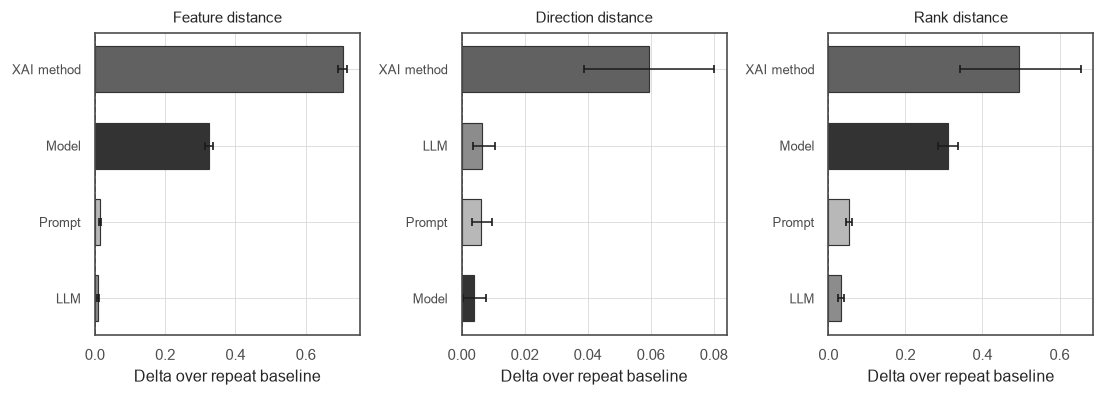

Saved: fig28_baseline_vs_changed.png / fig28_baseline_vs_changed.pdf


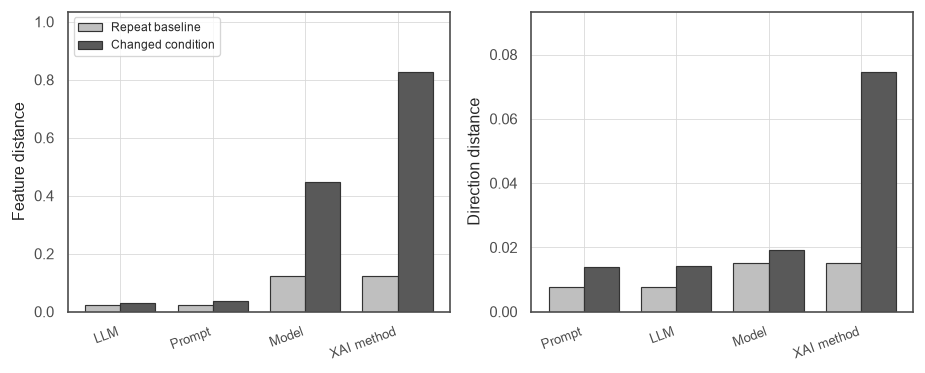

Saved: fig29_case_delta_distributions.png / fig29_case_delta_distributions.pdf


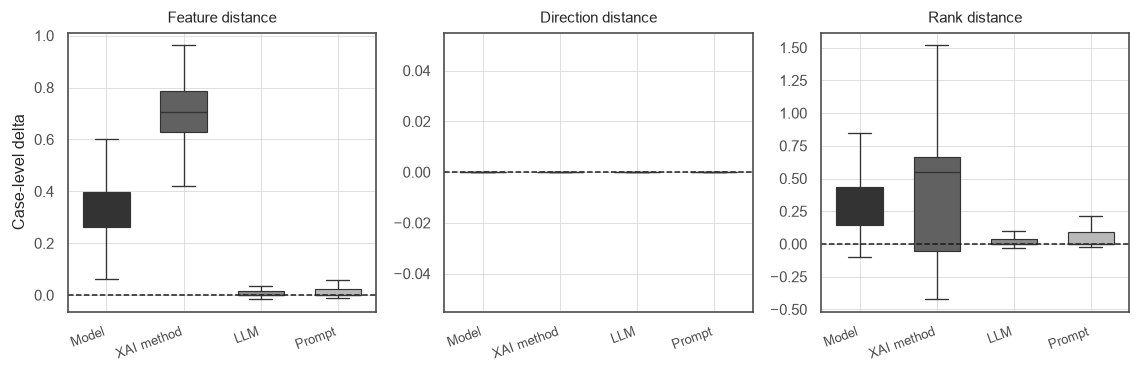

Saved: fig30_delta_cumulative_distribution.png / fig30_delta_cumulative_distribution.pdf


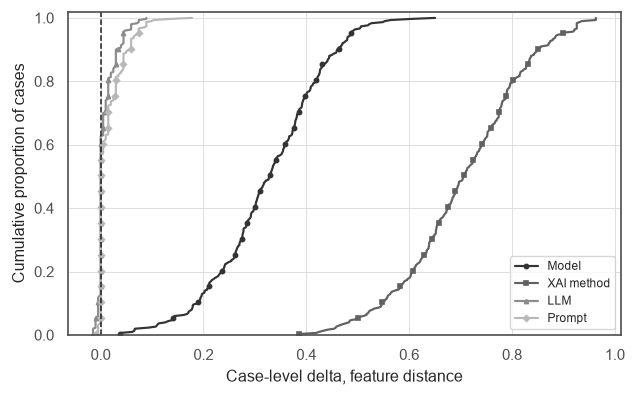

Saved: fig31_temperature_effect.png / fig31_temperature_effect.pdf


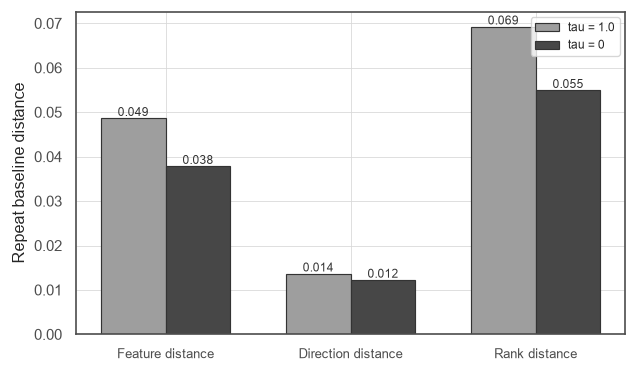

Saved: fig32_domain_comparison.png / fig32_domain_comparison.pdf


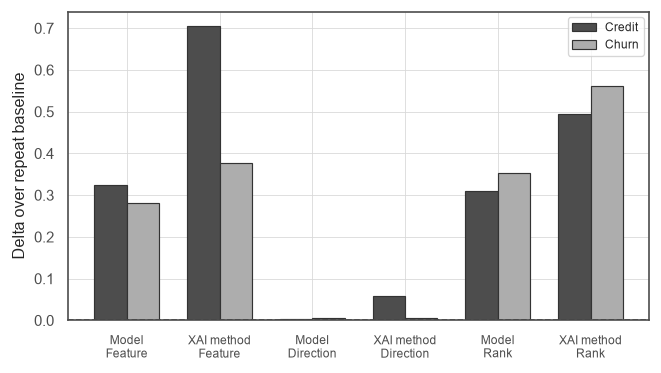

Saved: tab46_research_question_answers.csv
RQ5 is addressed separately in 11_quality_stability.ipynb


,RQ,Question,Delta,CI,Exceeds baseline
0,RQ1,Effect of model change,0.3250,"[0.3128, 0.3367]",True
1,RQ1,Effect of xai method change,0.7048,"[0.6917, 0.7182]",True
2,RQ2,Effect of llm change,0.0086,"[0.0066, 0.0107]",True
3,RQ2,Effect of prompt change,0.0157,"[0.0128, 0.0186]",True
4,RQ3,Instability under identical conditions,0.0486,"[0.0398, 0.0580]",True
5,RQ4,Largest source of additional instability,0.7048,"[0.6917, 0.7182]",XAI method ranks first
6,RQ6,Residual instability at tau = 0,0.0378,"[0.0296, 0.0464]",not eliminated


Saved: delta_manifest.json
Saved: logs/09_run_20260921.json
Outputs:
  results\tables\tab39_delta_main_results.csv
  results\tables\tab39_direction_resolution_by_condition.csv
  results\tables\tab40_instability_source_ranking.csv
  results\tables\tab41_factor_comparisons.csv
  results\tables\tab42_domain_comparison.csv
  results\tables\tab43_temperature_effect.csv
  results\tables\tab44_delta_distributions.csv
  results\tables\tab45_delta_coverage.csv
  results\tables\tab46_research_question_answers.csv
  results\figures\fig27_delta_by_factor.pdf
  results\figures\fig27_delta_by_factor.png
  results\figures\fig28_baseline_vs_changed.pdf
  results\figures\fig28_baseline_vs_changed.png
  results\figures\fig29_case_delta_distributions.pdf
  results\figures\fig29_case_delta_distributions.png
  results\figures\fig30_delta_cumulative_distribution.pdf
  results\figures\fig30_delta_cumulative_distribution.png
  results\figures\fig31_temperature_effect.pdf
  results\figures\fig31_temperature_ef

In [2]:
# ============================================================================
# 09_delta_analysis.ipynb
# Main analysis: additional instability relative to the repeat baseline
# Computes case-level deltas for each pipeline factor, estimates confidence
# intervals by case-level cluster bootstrap, and compares the domains. This
# notebook produces the headline results of the study.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
rng_global = np.random.default_rng(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})

FACTOR_SHADES = {
    "model_change": "0.20",
    "xai_change": "0.38",
    "llm_change": "0.55",
    "prompt_change": "0.72",
}
FACTOR_LABELS = {
    "model_change": "Model",
    "xai_change": "XAI method",
    "llm_change": "LLM",
    "prompt_change": "Prompt",
}


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Analysis configuration
B_BOOTSTRAP = 2000          # cluster bootstrap draws for reported intervals
CI_LEVEL = 0.95
MIN_CASES = 30              # minimum cases required to report a contrast

METRICS = ["feature_distance", "direction_distance", "rank_distance"]
METRIC_LABELS = {
    "feature_distance": "Feature distance",
    "direction_distance": "Direction distance",
    "rank_distance": "Rank distance",
}

# Only single-factor contrasts enter the main analysis. Pairs in which two or
# more factors differ cannot be attributed to a single source of instability.
MAIN_CONTRASTS = ["model_change", "xai_change", "llm_change", "prompt_change"]


# [Cell 4] Load the distance tables and study metadata
pairs = pd.read_parquet(DATA_DIR / "content_distances.parquet")
case_level = pd.read_parquet(DATA_DIR / "case_level_distances.parquet")

with open(DATA_DIR / "distance_manifest.json", encoding="utf-8") as f:
    distance_manifest = json.load(f)

with open(DATA_DIR / "validation_summary.json", encoding="utf-8") as f:
    validation = json.load(f)

RANK_PRIMARY = validation["rank_primary"]
PRIMARY_METRICS = ["feature_distance", "direction_distance"] + (
    ["rank_distance"] if RANK_PRIMARY else []
)

print(f"Pairs: {len(pairs):,}   case-level rows: {len(case_level):,}")
print(f"Primary metrics: {PRIMARY_METRICS}")
print(f"Contrast counts:\n{pairs['contrast'].value_counts().to_string()}")


# [Cell 5] Case-level delta construction
# Delta is a within-case contrast: for each case, the mean distance under a
# changed condition minus the mean distance when only the repetition index
# varies. Computing the difference case by case, rather than differencing two
# marginal means, preserves the pairing and removes between-case heterogeneity.
def build_case_deltas(case_df, block, contrasts=MAIN_CONTRASTS):
    """Case-level delta for each contrast within one block."""
    sub = case_df[case_df["block"] == block]
    baseline = sub[sub["contrast"] == "repeat"].set_index("case_id")

    rows = []
    for contrast in contrasts:
        changed = sub[sub["contrast"] == contrast].set_index("case_id")
        shared = baseline.index.intersection(changed.index)
        if len(shared) == 0:
            continue

        for case_id in shared:
            row = {
                "block": block,
                "domain": baseline.loc[case_id, "domain"],
                "case_id": case_id,
                "contrast": contrast,
            }
            for m in METRICS:
                b, c = baseline.loc[case_id, m], changed.loc[case_id, m]
                row[f"{m}_baseline"] = b
                row[f"{m}_changed"] = c
                row[f"{m}_delta"] = c - b if pd.notna(b) and pd.notna(c) else np.nan
            rows.append(row)

    return pd.DataFrame(rows)


blocks_present = sorted(case_level["block"].unique())
deltas = pd.concat(
    [build_case_deltas(case_level, b) for b in blocks_present],
    ignore_index=True,
)
deltas = deltas[deltas["contrast"].isin(MAIN_CONTRASTS)]

deltas.to_parquet(DATA_DIR / "case_deltas.parquet", index=False)
print(f"Case-level deltas: {len(deltas):,} rows")
print(deltas.groupby(["block", "contrast"]).size().to_string())


# [Cell 6] Cluster bootstrap
# Cases are the resampling unit. For a delta, the same resampled case index is
# applied to both the changed condition and the baseline, so that the paired
# structure survives resampling.
def cluster_bootstrap_mean(values_by_case, B=B_BOOTSTRAP, level=CI_LEVEL, rng=None):
    """Percentile interval for a mean, resampling whole cases."""
    rng = rng or np.random.default_rng(SEED)
    cases = np.array(list(values_by_case.keys()))
    if len(cases) < 2:
        return np.nan, np.nan, np.nan

    arrays = {c: np.atleast_1d(values_by_case[c]) for c in cases}
    point = float(np.nanmean(np.concatenate([arrays[c] for c in cases])))

    stats = np.empty(B)
    for i in range(B):
        picked = rng.choice(cases, size=len(cases), replace=True)
        vals = np.concatenate([arrays[c] for c in picked])
        stats[i] = np.nanmean(vals)

    alpha = (1 - level) / 2
    return point, float(np.nanquantile(stats, alpha)), float(np.nanquantile(stats, 1 - alpha))


def bootstrap_delta(delta_df, metric, B=B_BOOTSTRAP, level=CI_LEVEL, rng=None):
    """Point estimate and interval for a case-level delta."""
    col = f"{metric}_delta"
    valid = delta_df[[col, "case_id"]].dropna()
    if valid["case_id"].nunique() < MIN_CASES:
        return {"estimate": np.nan, "ci_low": np.nan, "ci_high": np.nan,
                "n_cases": valid["case_id"].nunique()}

    by_case = valid.groupby("case_id")[col].mean().to_dict()
    point, lo, hi = cluster_bootstrap_mean(by_case, B=B, level=level, rng=rng)

    return {
        "estimate": round(point, 4),
        "ci_low": round(lo, 4),
        "ci_high": round(hi, 4),
        "ci_halfwidth": round((hi - lo) / 2, 4),
        "n_cases": len(by_case),
        "excludes_zero": bool(lo > 0 or hi < 0),
    }


# [Cell 7] Main result: additional instability by factor
# The headline table of the study. Each row states how much more the explanation
# content changes when one pipeline factor is altered, over and above the
# variation produced by regenerating under identical conditions.
main_rows = []
rng = np.random.default_rng(SEED)

for block in blocks_present:
    block_deltas = deltas[deltas["block"] == block]
    if len(block_deltas) == 0:
        continue

    for contrast in MAIN_CONTRASTS:
        sub = block_deltas[block_deltas["contrast"] == contrast]
        if len(sub) == 0:
            continue

        for metric in METRICS:
            base_col, change_col = f"{metric}_baseline", f"{metric}_changed"
            res = bootstrap_delta(sub, metric, rng=rng)

            main_rows.append({
                "Block": block,
                "Domain": sub["domain"].iloc[0],
                "Factor": FACTOR_LABELS.get(contrast, contrast),
                "Metric": METRIC_LABELS[metric],
                "Baseline": round(float(sub[base_col].mean()), 4),
                "Changed": round(float(sub[change_col].mean()), 4),
                "Delta": res["estimate"],
                "CI low": res["ci_low"],
                "CI high": res["ci_high"],
                "N cases": res["n_cases"],
                "Excludes zero": res.get("excludes_zero"),
                "Primary": metric in PRIMARY_METRICS,
            })

main_results = pd.DataFrame(main_rows)
save_table(main_results, "tab39_delta_main_results")

print("\nPrimary metrics, primary domain:")
print(
    main_results[
        (main_results["Primary"]) & (main_results["Block"] == "A")
    ].to_string(index=False)
)


# [Cell 8] Ranking the sources of instability
# Answers RQ4 directly: which pipeline component contributes the most additional
# instability. Ranking is done within each metric so that the ordering does not
# depend on the arbitrary scale differences between metrics.
rank_rows = []
for metric in PRIMARY_METRICS:
    sub = main_results[
        (main_results["Metric"] == METRIC_LABELS[metric])
        & (main_results["Block"].isin(["A", "B"]))
    ].copy()
    if len(sub) == 0:
        continue

    sub = sub.sort_values("Delta", ascending=False).reset_index(drop=True)
    for i, r in sub.iterrows():
        rank_rows.append({
            "Metric": METRIC_LABELS[metric],
            "Rank": i + 1,
            "Factor": r["Factor"],
            "Block": r["Block"],
            "Delta": r["Delta"],
            "CI": f"[{r['CI low']}, {r['CI high']}]",
            "Excludes zero": r["Excludes zero"],
        })

source_ranking = pd.DataFrame(rank_rows)
save_table(source_ranking, "tab40_instability_source_ranking")
display(source_ranking)


# [Cell 9] Pairwise comparison between factors
# Establishes whether one factor produces significantly more instability than
# another. Cases shared between the two contrasts are differenced within case,
# then bootstrapped, so that the comparison is paired rather than marginal.
def compare_factors(delta_df, contrast_a, contrast_b, metric,
                    B=B_BOOTSTRAP, rng=None):
    """Paired comparison of two factors' deltas on the shared cases."""
    col = f"{metric}_delta"
    a = delta_df[delta_df["contrast"] == contrast_a].set_index("case_id")[col]
    b = delta_df[delta_df["contrast"] == contrast_b].set_index("case_id")[col]
    shared = a.dropna().index.intersection(b.dropna().index)

    if len(shared) < MIN_CASES:
        return None

    diff = (a.loc[shared] - b.loc[shared]).to_dict()
    point, lo, hi = cluster_bootstrap_mean(diff, B=B, rng=rng)

    return {
        "Metric": METRIC_LABELS[metric],
        "Comparison": f"{FACTOR_LABELS[contrast_a]} - {FACTOR_LABELS[contrast_b]}",
        "Difference": round(point, 4),
        "CI low": round(lo, 4),
        "CI high": round(hi, 4),
        "N cases": len(shared),
        "Excludes zero": bool(lo > 0 or hi < 0),
    }


comparison_rows = []
rng = np.random.default_rng(SEED + 1)

for metric in PRIMARY_METRICS:
    for block in ["A", "B"]:
        block_deltas = deltas[deltas["block"] == block]
        available = [c for c in MAIN_CONTRASTS
                     if c in set(block_deltas["contrast"])]
        for a, b in combinations(available, 2):
            res = compare_factors(block_deltas, a, b, metric, rng=rng)
            if res:
                res["Block"] = block
                comparison_rows.append(res)

factor_comparisons = pd.DataFrame(comparison_rows)
if len(factor_comparisons):
    save_table(factor_comparisons, "tab41_factor_comparisons")
display(factor_comparisons)


# [Cell 10] Domain comparison
# Blocks A and A' share an identical design in different domains. Comparing the
# deltas tests whether the instability pattern is specific to the high-impact
# domain or general. Cases are not shared across domains, so this comparison is
# unpaired and uses an independent-cluster bootstrap.
def compare_domains(delta_df, contrast, metric, B=B_BOOTSTRAP, rng=None):
    """Unpaired comparison of a delta between Block A and Block A'."""
    col = f"{metric}_delta"
    a = delta_df[(delta_df["block"] == "A") & (delta_df["contrast"] == contrast)]
    b = delta_df[(delta_df["block"] == "A_prime") & (delta_df["contrast"] == contrast)]

    a_by_case = a.groupby("case_id")[col].mean().dropna()
    b_by_case = b.groupby("case_id")[col].mean().dropna()

    if len(a_by_case) < MIN_CASES or len(b_by_case) < MIN_CASES:
        return None

    rng = rng or np.random.default_rng(SEED)
    stats = np.empty(B)
    av, bv = a_by_case.values, b_by_case.values
    for i in range(B):
        sa = rng.choice(av, size=len(av), replace=True)
        sb = rng.choice(bv, size=len(bv), replace=True)
        stats[i] = sa.mean() - sb.mean()

    alpha = (1 - CI_LEVEL) / 2
    lo, hi = float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))

    return {
        "Metric": METRIC_LABELS[metric],
        "Factor": FACTOR_LABELS[contrast],
        "Credit delta": round(float(av.mean()), 4),
        "Churn delta": round(float(bv.mean()), 4),
        "Difference": round(float(av.mean() - bv.mean()), 4),
        "CI low": round(lo, 4),
        "CI high": round(hi, 4),
        "Excludes zero": bool(lo > 0 or hi < 0),
    }


domain_rows = []
rng = np.random.default_rng(SEED + 2)
for metric in PRIMARY_METRICS:
    for contrast in ["model_change", "xai_change"]:
        res = compare_domains(deltas, contrast, metric, rng=rng)
        if res:
            domain_rows.append(res)

domain_comparison = pd.DataFrame(domain_rows)
if len(domain_comparison):
    save_table(domain_comparison, "tab42_domain_comparison")

    n_diff = int(domain_comparison["Excludes zero"].sum())
    print(f"\nDomain differences excluding zero: {n_diff} of {len(domain_comparison)}")
    print("Note: the control domain covers Block A only, so domain "
          "generalisation of the LLM and prompt effects is not established.")
display(domain_comparison)


# [Cell 11] Temperature comparison
# Addresses RQ6. Blocks D and D-0 differ only in the decoding temperature, so
# the contrast isolates whether deterministic decoding removes the repeat
# baseline instability.
deep_repeat = case_level[
    (case_level["block"].isin(["D", "D0"])) & (case_level["contrast"] == "repeat")
]

temp_rows = []
rng = np.random.default_rng(SEED + 3)

for metric in METRICS:
    d1 = deep_repeat[deep_repeat["block"] == "D"].groupby("case_id")[metric].mean().dropna()
    d0 = deep_repeat[deep_repeat["block"] == "D0"].groupby("case_id")[metric].mean().dropna()
    shared = d1.index.intersection(d0.index)

    if len(shared) < MIN_CASES:
        continue

    # Cases are shared between the two blocks, so the comparison is paired
    diff = (d1.loc[shared] - d0.loc[shared]).to_dict()
    point, lo, hi = cluster_bootstrap_mean(diff, rng=rng)

    b1, l1, h1 = cluster_bootstrap_mean(d1.loc[shared].to_dict(), rng=rng)
    b0, l0, h0 = cluster_bootstrap_mean(d0.loc[shared].to_dict(), rng=rng)

    temp_rows.append({
        "Metric": METRIC_LABELS[metric],
        "Baseline tau=1.0": round(b1, 4),
        "CI tau=1.0": f"[{l1:.4f}, {h1:.4f}]",
        "Baseline tau=0": round(b0, 4),
        "CI tau=0": f"[{l0:.4f}, {h0:.4f}]",
        "Reduction": round(point, 4),
        "CI low": round(lo, 4),
        "CI high": round(hi, 4),
        "N cases": len(shared),
        "Residual instability at tau=0": round(b0, 4),
        "Excludes zero": bool(lo > 0 or hi < 0),
    })

temperature_effect = pd.DataFrame(temp_rows)
save_table(temperature_effect, "tab43_temperature_effect")

if len(temperature_effect):
    residual = temperature_effect.loc[0, "Residual instability at tau=0"]
    print(f"\nResidual instability under deterministic decoding: {residual}")
    print("A non-zero residual establishes that temperature control alone does "
          "not deliver content reproducibility.")
display(temperature_effect)


# [Cell 12] Delta distributions, not just means
# The research design specifies that deltas are reported as distributions.
# A moderate mean can conceal a subset of cases whose explanations change
# substantially when a pipeline component is altered.
dist_rows = []
for block in ["A", "B"]:
    for contrast in MAIN_CONTRASTS:
        sub = deltas[(deltas["block"] == block) & (deltas["contrast"] == contrast)]
        if len(sub) < MIN_CASES:
            continue
        for metric in PRIMARY_METRICS:
            vals = sub[f"{metric}_delta"].dropna()
            if len(vals) < MIN_CASES:
                continue
            dist_rows.append({
                "Block": block,
                "Factor": FACTOR_LABELS[contrast],
                "Metric": METRIC_LABELS[metric],
                "Mean": round(float(vals.mean()), 4),
                "Median": round(float(vals.median()), 4),
                "Q1": round(float(vals.quantile(0.25)), 4),
                "Q3": round(float(vals.quantile(0.75)), 4),
                "P90": round(float(vals.quantile(0.90)), 4),
                "Share above 0.10": round(float((vals > 0.10).mean()), 4),
                "Share above 0.20": round(float((vals > 0.20).mean()), 4),
                "Share negative": round(float((vals < 0).mean()), 4),
            })

delta_distributions = pd.DataFrame(dist_rows)
save_table(delta_distributions, "tab44_delta_distributions")
display(delta_distributions)


# [Cell 13] Negative deltas
# A negative delta means a changed condition produced less content variation
# than repeated generation under identical settings. This is not an anomaly:
# it occurs when a constrained condition suppresses variation that free
# regeneration would otherwise introduce. Its frequency is reported so that the
# delta framing is not read as strictly positive by construction.
neg_share = delta_distributions["Share negative"].describe().round(4)
print("Share of cases with a negative delta:")
print(neg_share.to_string())

if delta_distributions["Share negative"].max() > 0.30:
    print("\nNOTE: in some cells more than 30 per cent of cases show a negative "
          "delta. Report the full distribution rather than the mean alone.")


# [Cell 14] Sensitivity: excluding cases with undefined distances
# Direction distance is undefined when two explanations share no features.
# Excluding those cases could bias the estimate downward, since they represent
# the most extreme divergence. This check quantifies the exposure.
sens_rows = []
for metric in PRIMARY_METRICS:
    for block in ["A", "B"]:
        for contrast in MAIN_CONTRASTS:
            sub = deltas[(deltas["block"] == block) & (deltas["contrast"] == contrast)]
            if len(sub) < MIN_CASES:
                continue
            col = f"{metric}_delta"
            sens_rows.append({
                "Block": block,
                "Factor": FACTOR_LABELS[contrast],
                "Metric": METRIC_LABELS[metric],
                "N cases total": sub["case_id"].nunique(),
                "N cases with value": int(sub[col].notna().sum()),
                "Undefined share": round(float(sub[col].isna().mean()), 4),
            })

sensitivity = pd.DataFrame(sens_rows)
save_table(sensitivity, "tab45_delta_coverage")

max_undef = sensitivity["Undefined share"].max()
print(f"Maximum undefined share across cells: {max_undef:.4f}")
if max_undef > 0.20:
    print("NOTE: substantial undefined coverage. Cases where explanations share "
          "no features are excluded by construction and represent the most "
          "extreme divergence; report this alongside the estimates.")
display(sensitivity)


# [Cell 15] Figure: additional instability by factor
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(3.1 * len(PRIMARY_METRICS), 3.4))
if len(PRIMARY_METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, PRIMARY_METRICS):
    sub = main_results[
        (main_results["Metric"] == METRIC_LABELS[metric])
        & (main_results["Block"].isin(["A", "B"]))
    ].dropna(subset=["Delta"]).sort_values("Delta")

    y = np.arange(len(sub))
    shades = [
        FACTOR_SHADES.get(
            next(k for k, v in FACTOR_LABELS.items() if v == f), "0.5"
        )
        for f in sub["Factor"]
    ]

    ax.barh(
        y, sub["Delta"], height=0.6,
        color=shades, edgecolor="0.2", linewidth=0.7,
    )
    ax.errorbar(
        sub["Delta"], y,
        xerr=[sub["Delta"] - sub["CI low"], sub["CI high"] - sub["Delta"]],
        fmt="none", ecolor="0.1", elinewidth=0.9, capsize=2.5,
    )
    ax.axvline(0, color="0.1", linestyle="--", linewidth=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["Factor"], fontsize=8)
    ax.set_xlabel("Delta over repeat baseline")
    ax.set_title(METRIC_LABELS[metric], fontsize=9, color="0.15")

plt.tight_layout()
save_fig(fig, "fig27_delta_by_factor")
plt.show()


# [Cell 16] Figure: baseline and changed levels side by side
# Shows the absolute levels behind each delta, so that a large delta on a small
# baseline is not read as equivalent to the same delta on a large one.
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.2))

for ax, metric in zip(axes, PRIMARY_METRICS[:2]):
    sub = main_results[
        (main_results["Metric"] == METRIC_LABELS[metric])
        & (main_results["Block"].isin(["A", "B"]))
    ].dropna(subset=["Delta"]).sort_values("Changed")

    x = np.arange(len(sub))
    width = 0.38

    ax.bar(x - width / 2, sub["Baseline"], width,
           color="0.75", edgecolor="0.2", linewidth=0.7, label="Repeat baseline")
    ax.bar(x + width / 2, sub["Changed"], width,
           color="0.35", edgecolor="0.2", linewidth=0.7, label="Changed condition")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["Factor"], fontsize=7.5, rotation=20, ha="right")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_ylim(0, max(sub["Changed"].max(), sub["Baseline"].max()) * 1.25)
    if metric == PRIMARY_METRICS[0]:
        ax.legend(fontsize=7, frameon=True, loc="upper left")

plt.tight_layout()
save_fig(fig, "fig28_baseline_vs_changed")
plt.show()


# [Cell 17] Figure: case-level delta distributions
fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(3.2 * len(PRIMARY_METRICS), 3.2))
if len(PRIMARY_METRICS) == 1:
    axes = [axes]

contrasts_present = [
    c for c in MAIN_CONTRASTS
    if c in set(deltas[deltas["block"].isin(["A", "B"])]["contrast"])
]

for ax, metric in zip(axes, PRIMARY_METRICS):
    data, labels, shades = [], [], []
    for c in contrasts_present:
        vals = deltas[
            (deltas["block"].isin(["A", "B"])) & (deltas["contrast"] == c)
        ][f"{metric}_delta"].dropna()
        if len(vals) >= MIN_CASES:
            data.append(vals)
            labels.append(FACTOR_LABELS[c])
            shades.append(FACTOR_SHADES[c])

    bp = ax.boxplot(data, widths=0.6, patch_artist=True, showfliers=False)
    for patch, s in zip(bp["boxes"], shades):
        patch.set_facecolor(s)
        patch.set_edgecolor("0.2")
        patch.set_linewidth(0.7)
    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set_color("0.2")
            item.set_linewidth(0.8)

    ax.axhline(0, color="0.1", linestyle="--", linewidth=0.9)
    ax.set_xticklabels(labels, fontsize=7.5, rotation=20, ha="right")
    ax.set_ylabel("Case-level delta" if metric == PRIMARY_METRICS[0] else "")
    ax.set_title(METRIC_LABELS[metric], fontsize=9, color="0.15")

plt.tight_layout()
save_fig(fig, "fig29_case_delta_distributions")
plt.show()


# [Cell 18] Figure: cumulative distribution of case-level deltas
# Makes the tail visible: the proportion of cases whose explanations change
# substantially is more decision-relevant than the average change.
fig, ax = plt.subplots(figsize=(5.4, 3.4))

markers = ["o", "s", "^", "D"]
for i, c in enumerate(contrasts_present):
    vals = np.sort(
        deltas[
            (deltas["block"].isin(["A", "B"])) & (deltas["contrast"] == c)
        ]["feature_distance_delta"].dropna().values
    )
    if len(vals) < MIN_CASES:
        continue
    ax.plot(
        vals, np.arange(1, len(vals) + 1) / len(vals),
        color=FACTOR_SHADES[c], linewidth=1.3,
        marker=markers[i % 4], markersize=2.5, markevery=max(1, len(vals) // 20),
        label=FACTOR_LABELS[c],
    )

ax.axvline(0, color="0.1", linestyle="--", linewidth=0.9)
ax.set_xlabel("Case-level delta, feature distance")
ax.set_ylabel("Cumulative proportion of cases")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=7, frameon=True, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig30_delta_cumulative_distribution")
plt.show()


# [Cell 19] Figure: temperature effect on the repeat baseline
if len(temperature_effect):
    fig, ax = plt.subplots(figsize=(5.4, 3.2))

    metrics_present = temperature_effect["Metric"].tolist()
    x = np.arange(len(metrics_present))
    width = 0.35

    ax.bar(x - width / 2, temperature_effect["Baseline tau=1.0"], width,
           color="0.62", edgecolor="0.2", linewidth=0.7, label="tau = 1.0")
    ax.bar(x + width / 2, temperature_effect["Baseline tau=0"], width,
           color="0.28", edgecolor="0.2", linewidth=0.7, label="tau = 0")

    for i, (v1, v0) in enumerate(zip(
        temperature_effect["Baseline tau=1.0"], temperature_effect["Baseline tau=0"]
    )):
        ax.text(i - width / 2, v1, f"{v1:.3f}", ha="center", va="bottom",
                fontsize=7, color="0.2")
        ax.text(i + width / 2, v0, f"{v0:.3f}", ha="center", va="bottom",
                fontsize=7, color="0.2")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_present, fontsize=8)
    ax.set_ylabel("Repeat baseline distance")
    ax.legend(fontsize=7, frameon=True, loc="upper right")

    plt.tight_layout()
    save_fig(fig, "fig31_temperature_effect")
    plt.show()


# [Cell 20] Figure: domain comparison
if len(domain_comparison):
    fig, ax = plt.subplots(figsize=(5.6, 3.2))

    labels = [
        f"{r['Factor']}\n{r['Metric'].replace(' distance', '')}"
        for _, r in domain_comparison.iterrows()
    ]
    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width / 2, domain_comparison["Credit delta"], width,
           color="0.30", edgecolor="0.2", linewidth=0.7, label="Credit")
    ax.bar(x + width / 2, domain_comparison["Churn delta"], width,
           color="0.68", edgecolor="0.2", linewidth=0.7, label="Churn")

    ax.axhline(0, color="0.1", linestyle="--", linewidth=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel("Delta over repeat baseline")
    ax.legend(fontsize=7, frameon=True, loc="upper right")

    plt.tight_layout()
    save_fig(fig, "fig32_domain_comparison")
    plt.show()


# [Cell 21] Answers to the research questions
# Each research question is answered from the tables above, with the supporting
# quantity attached so that the narrative in the paper is traceable to output.
def lookup(block, factor, metric):
    """Retrieve a delta row from the main results."""
    r = main_results[
        (main_results["Block"] == block)
        & (main_results["Factor"] == factor)
        & (main_results["Metric"] == METRIC_LABELS[metric])
    ]
    return r.iloc[0] if len(r) else None


answers = []

# RQ1: model and XAI change
for factor in ["Model", "XAI method"]:
    r = lookup("A", factor, "feature_distance")
    if r is not None:
        answers.append({
            "RQ": "RQ1",
            "Question": f"Effect of {factor.lower()} change",
            "Delta": r["Delta"],
            "CI": f"[{r['CI low']}, {r['CI high']}]",
            "Exceeds baseline": r["Excludes zero"],
        })

# RQ2: LLM and prompt change
for factor in ["LLM", "Prompt"]:
    r = lookup("B", factor, "feature_distance")
    if r is not None:
        answers.append({
            "RQ": "RQ2",
            "Question": f"Effect of {factor.lower()} change",
            "Delta": r["Delta"],
            "CI": f"[{r['CI low']}, {r['CI high']}]",
            "Exceeds baseline": r["Excludes zero"],
        })

# RQ3: instability under identical conditions
base_row = (
    case_level[(case_level["block"] == "D") & (case_level["contrast"] == "repeat")]
)
if len(base_row):
    bpoint, blo, bhi = cluster_bootstrap_mean(
        base_row.groupby("case_id")["feature_distance"].mean().dropna().to_dict(),
        rng=np.random.default_rng(SEED + 4),
    )
    answers.append({
        "RQ": "RQ3",
        "Question": "Instability under identical conditions",
        "Delta": round(bpoint, 4),
        "CI": f"[{blo:.4f}, {bhi:.4f}]",
        "Exceeds baseline": bool(blo > 0),
    })

# RQ4: dominant source
if len(source_ranking):
    top = source_ranking[
        source_ranking["Metric"] == METRIC_LABELS["feature_distance"]
    ].iloc[0]
    answers.append({
        "RQ": "RQ4",
        "Question": "Largest source of additional instability",
        "Delta": top["Delta"],
        "CI": top["CI"],
        "Exceeds baseline": f"{top['Factor']} ranks first",
    })

# RQ6: deterministic decoding
if len(temperature_effect):
    t = temperature_effect.iloc[0]
    answers.append({
        "RQ": "RQ6",
        "Question": "Residual instability at tau = 0",
        "Delta": t["Baseline tau=0"],
        "CI": t["CI tau=0"],
        "Exceeds baseline": "not eliminated" if t["Baseline tau=0"] > 0 else "eliminated",
    })

rq_answers = pd.DataFrame(answers)
save_table(rq_answers, "tab46_research_question_answers")
print("RQ5 is addressed separately in 11_quality_stability.ipynb")
display(rq_answers)


# [Cell 22] Persist the analysis manifest
manifest = {
    "notebook": "09_delta_analysis",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "bootstrap_draws": B_BOOTSTRAP,
    "ci_level": CI_LEVEL,
    "min_cases": MIN_CASES,
    "primary_metrics": PRIMARY_METRICS,
    "rank_primary": RANK_PRIMARY,
    "main_contrasts": MAIN_CONTRASTS,
    "n_case_deltas": int(len(deltas)),
    "main_results": main_results.to_dict(orient="records"),
    "source_ranking": source_ranking.to_dict(orient="records"),
    "temperature_effect": temperature_effect.to_dict(orient="records"),
    "domain_comparison": domain_comparison.to_dict(orient="records"),
    "rq_answers": rq_answers.to_dict(orient="records"),
}

with open(DATA_DIR / "delta_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print("Saved: delta_manifest.json")

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"09_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/09_run_{stamp}.json")


# [Cell 23] Verification and handover notes
print("Outputs:")
for p in sorted(TAB_DIR.glob("tab3[9]*")) + sorted(TAB_DIR.glob("tab4[0-6]*")) \
        + sorted(FIG_DIR.glob("fig2[7-9]*")) + sorted(FIG_DIR.glob("fig3[0-2]*")):
    print(f"  {p.relative_to(ROOT)}")

print(f"""
Headline quantities
-------------------
Case-level deltas computed  {len(deltas):,}
Contrasts reported          {', '.join(FACTOR_LABELS[c] for c in MAIN_CONTRASTS)}
Bootstrap draws             {B_BOOTSTRAP:,}

Interpretation notes for the write-up
  - Deltas are case-level contrasts against the repeat baseline. A delta of
    zero means a changed condition produces no more variation than regenerating
    under identical settings.
  - Negative deltas occur and are reported. They indicate conditions that
    suppress variation relative to free regeneration.
  - Distances are undefined when two explanations share no features. Those
    cases are the most divergent and are excluded by construction; the coverage
    table records the exposure.
  - The control domain covers Block A only, so domain generalisation of the
    LLM and prompt effects is not established.

Next step: 10_mixed_effects.ipynb (robustness check)
""")

In [3]:
import pandas as pd
for t in ["tab39_delta_main_results", "tab40_instability_source_ranking",
          "tab43_temperature_effect", "tab46_research_question_answers"]:
    print(f"\n=== {t} ===")
    print(pd.read_csv(f"../results/tables/{t}.csv").to_string(index=False))


=== tab39_delta_main_results ===
  Block Domain     Factor             Metric  Baseline  Changed  Delta  CI low  CI high  N cases Excludes zero  Primary
      A credit      Model   Feature distance    0.1234   0.4485 0.3250  0.3128   0.3367      300          True     True
      A credit      Model Direction distance    0.0153   0.0192 0.0039  0.0005   0.0079      300          True     True
      A credit      Model      Rank distance    0.0798   0.3892 0.3094  0.2848   0.3359      300          True     True
      A credit XAI method   Feature distance    0.1234   0.8282 0.7048  0.6917   0.7182      300          True     True
      A credit XAI method Direction distance    0.0153   0.0747 0.0594  0.0387   0.0801      299          True     True
      A credit XAI method      Rank distance    0.0798   0.5969 0.4957  0.3427   0.6553       58          True     True
A_prime  churn      Model   Feature distance    0.1073   0.3894 0.2822  0.2713   0.2925      300          True     True
A_prim